# Instacart: simple data cleaning, before and after

**Member 1 — five easy steps, real examples, and simple charts**

This notebook uses **all six complete source files**, not a sample. Its purpose
is to make the data ready for the team's database and analysis work.

| Step | What we do | What you can explain |
| --- | --- | --- |
| 1 | Open and understand the data | What each table and row means |
| 2 | Clean spaces in product names | Actual names before and after |
| 3 | Check blanks, NULLs, and zeros | Why first-order blanks must stay missing |
| 4 | Check duplicates and invalid values | Which records should be kept and why |
| 5 | Compare, visualize, and export | Simple patterns and files for the team |

**Actual corrections:** standardize inconsistent spacing in **424 product
names**. **Decisions:** retain meaningful missing values, distinct product
IDs, valid zeros, and valid large baskets. No source records are deleted.
Checks that find zero errors are reported honestly; no artificial errors are
added to the dataset.

**How to run:** open in Jupyter or Colab and run all cells in order. Put the six
original CSVs in `raw_data/`; the notebook can download missing files. Install
`pandas`, `numpy`, and `matplotlib` if needed. The full dataset needs a few GB
of free RAM. The original CSV files are left unchanged.

**Sources:** [Instacart dataset](https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis)
and [data descriptions](https://gist.github.com/jeremystan/c3b39d947d9b88b3ccff3147dbcf6c6b).

In [1]:
from pathlib import Path
import csv, hashlib, json, re, shutil, unicodedata, urllib.request, zipfile, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
try:
    from IPython.display import display
except ImportError:
    if 'display' not in globals():
        def display(value):
            print(value.to_string(index=False) if isinstance(value,pd.DataFrame) else value)

pd.set_option('display.max_rows', 25)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_colwidth', 90)
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.spines.top':False,'axes.spines.right':False,'figure.facecolor':'white','axes.facecolor':'white'})
RAW_DIR = Path('raw_data')
if not RAW_DIR.exists() and Path('Instacart_Member1/data/raw').is_dir():
    RAW_DIR = Path('Instacart_Member1/data/raw')
OUT_DIR = Path('Instacart_Cleaned_Data')
TABLE_DIR, AUDIT_DIR, FIG_DIR = [OUT_DIR / x for x in ['tables','audit','figures']]
for directory in [TABLE_DIR,AUDIT_DIR,FIG_DIR]:
    directory.mkdir(parents=True,exist_ok=True)
DOWNLOAD_IF_MISSING = True
CHUNK_SIZE = 500_000
START = time.monotonic()
SCHEMAS = {
 'orders.csv':['order_id','user_id','eval_set','order_number','order_dow','order_hour_of_day','days_since_prior_order'],
 'products.csv':['product_id','product_name','aisle_id','department_id'],
 'aisles.csv':['aisle_id','aisle'],
 'departments.csv':['department_id','department'],
 'order_products__prior.csv':['order_id','product_id','add_to_cart_order','reordered'],
 'order_products__train.csv':['order_id','product_id','add_to_cart_order','reordered']}
checks, inventory, field_profiles, type_changes, label_changes = [], [], [], [], []

def check(name, count, rule, scope='all rows'):
    checks.append({'check':name,'scope':scope,'issue_count':int(count),
                   'status':'PASS' if count==0 else 'REVIEW','rule':rule})

def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(4*1024*1024),b''):
            h.update(block)
    return h.hexdigest()

def canonical_label(value):
    # Clean spaces only; preserve spelling, case, punctuation, and sizes.
    return re.sub(r'\s+',' ',str(value)).strip()

def duplicates_in_entire_array(values):
    values.sort()
    return int(np.count_nonzero(values[1:]==values[:-1]))

def required_integer(series, field):
    numeric=pd.to_numeric(series,errors='coerce')
    bad=numeric.isna() | numeric.mod(1).ne(0)
    check(field+': missing, malformed, or fractional integer',bad.sum(),'Required numeric fields must be nonmissing integers.')
    if bad.any():
        raise ValueError(f'{field}: investigate {int(bad.sum())} invalid values before export.')
    return numeric

def show_figure(fig,name):
    fig.tight_layout()
    fig.savefig(FIG_DIR/name,dpi=180,bbox_inches='tight')
    plt.show()
    plt.close(fig)

print('Raw source directory:',RAW_DIR)
print('Output directory:',OUT_DIR)
print('All six source files will be checked; no sampling.')

Raw source directory: raw_data
Output directory: Instacart_Cleaned_Data
All six source files will be checked; no sampling.


## Step 1 — Open the data and understand the columns

| Source file | What one row means |
| --- | --- |
| products.csv | One product and its category IDs |
| aisles.csv | One aisle/category label |
| departments.csv | One department label |
| orders.csv | One customer's order, including its hour and sequence number |
| order_products__prior.csv | One product in an earlier order |
| order_products__train.csv | One product in a supplied final training order |

Important columns: `order_id` identifies an order; `product_id` identifies a
product; `order_number` tells whether it is the customer's first, second, or
later order; `days_since_prior_order` is the gap from the previous order.
`reordered` is a 0/1 flag indicating a previous purchase by that customer.

The purchase files are large, so we check them in smaller pieces in Step 4.
Those checks still cover every row. The table below initially shows the four
smaller tables; the complete six-file count appears after the full scan.

In [2]:
RAW_DIR.mkdir(parents=True,exist_ok=True)
for filename in SCHEMAS:
    target=RAW_DIR/filename
    if not target.exists():
        if not DOWNLOAD_IF_MISSING:
            raise FileNotFoundError(f'Put {filename} into {RAW_DIR} or enable download.')
        url='https://www.kaggle.com/api/v1/datasets/download/psparks/instacart-market-basket-analysis/'+filename
        transfer, extracted = RAW_DIR/(filename+'.transfer.tmp'), RAW_DIR/(filename+'.extract.tmp')
        try:
            with urllib.request.urlopen(url,timeout=60) as response, transfer.open('wb') as out:
                expected=response.headers.get('Content-Length')
                shutil.copyfileobj(response,out,length=1024*1024)
            if expected and transfer.stat().st_size!=int(expected):
                raise ValueError('Transfer-size mismatch: incomplete source download.')
            if zipfile.is_zipfile(transfer):
                with zipfile.ZipFile(transfer) as archive:
                    if archive.namelist()!=[filename]:
                        raise ValueError('Unexpected archive contents.')
                    with archive.open(filename) as src, extracted.open('wb') as out:
                        shutil.copyfileobj(src,out,length=1024*1024)
            else:
                shutil.copyfile(transfer,extracted)
            extracted.replace(target)
            print('Downloaded:',filename)
        finally:
            transfer.unlink(missing_ok=True)
            extracted.unlink(missing_ok=True)
    with target.open(encoding='utf-8-sig',newline='') as f:
        header=next(csv.reader(f))
    normalized_header=[re.sub(r'\s+','_',h.strip().lower()) for h in header]
    check(filename+': header/schema mismatch',0 if normalized_header==SCHEMAS[filename] else 1,'Expected documented columns and order.',filename)
    if normalized_header!=SCHEMAS[filename]:
        raise ValueError('Inspect schema mismatch before proceeding.')
manifest=pd.DataFrame([{'file':f,'bytes':(RAW_DIR/f).stat().st_size,'sha256':sha256(RAW_DIR/f)} for f in SCHEMAS])
manifest.to_csv(AUDIT_DIR/'raw_source_manifest.csv',index=False)
display(manifest[['file','bytes']])

file,bytes
orders.csv,108968645
products.csv,2166953
aisles.csv,2603
departments.csv,270
order_products__prior.csv,577550706
order_products__train.csv,24680147


In [3]:
raw = {}
KEYS = {'products.csv':['product_id'], 'aisles.csv':['aisle_id'],
        'departments.csv':['department_id'], 'orders.csv':['order_id']}
TEXT = {'product_name','aisle','department','eval_set'}
for filename in KEYS:
    frame = pd.read_csv(RAW_DIR/filename, keep_default_na=False, low_memory=False)
    raw[filename] = frame
    inventory.append({'file':filename, 'rows':len(frame), 'columns':len(frame.columns)})
    check(filename+': duplicate primary keys', frame.duplicated(KEYS[filename]).sum(), 'Entity IDs must be unique.', filename)
    check(filename+': identical duplicate records', frame.duplicated().sum(), 'Check complete identical rows.', filename)
    for col in frame:
        blank = frame[col].astype(str).str.strip().eq('') | frame[col].isna()
        field_profiles.append({'file':filename,'column':col,'missing_or_blank':int(blank.sum()),
                               'distinct_nonblank':int(frame.loc[~blank,col].nunique()),'raw_dtype':str(frame[col].dtype)})
clean = {filename:frame.copy() for filename,frame in raw.items()}
display(pd.DataFrame(inventory).rename(columns={'file':'Source table','rows':'Rows','columns':'Columns'}))
display(raw['products.csv'].head(5))
display(raw['orders.csv'][['order_id','user_id','order_number','order_hour_of_day','days_since_prior_order']].head(5))

Source table,Rows,Columns
products.csv,49688,4
aisles.csv,134,2
departments.csv,21,2
orders.csv,3421083,7


product_id,product_name,aisle_id,department_id
1,Chocolate Sandwich Cookies,61,19
2,All-Seasons Salt,104,13
3,Robust Golden Unsweetened Oolong Tea,94,7
4,Smart Ones Classic Favorites Mini Rigatoni With Vodka Cream Sauce,38,1
5,Green Chile Anytime Sauce,5,13


order_id,user_id,order_number,order_hour_of_day,days_since_prior_order
2539329,1,1,8,
2398795,1,2,7,15.0
473747,1,3,12,21.0
2254736,1,4,7,29.0
431534,1,5,15,28.0


## Step 2 — Fix formatting: extra spaces in names

We make three simple corrections:

1. Remove spaces at the beginning or end of a name.
2. Replace an unusual **no-break space** with a normal space.
3. Replace repeated spaces with one space.

We keep the product's spelling, capital letters, size, punctuation, and ID.
The same rule is checked for aisle and department names.

**Useful later:** consistent labels make exact text searches, dropdowns,
displayed names, and comparison tables easier to use. Database joins still use
IDs. Cleaning a name does not prove two IDs refer to the same product.

In [4]:
label_changes, format_screen = [], []
for filename, field in [('products.csv','product_name'), ('aisles.csv','aisle'), ('departments.csv','department')]:
    before = raw[filename][field]
    after = (before.str.strip()
                   .str.replace(' ',' ',regex=False)
                   .str.replace(r'\s+',' ',regex=True))
    clean[filename][field] = after
    changed = before.ne(after)
    format_screen.append({'Table':filename,'Leading/trailing spaces':int(before.ne(before.str.strip()).sum()),
                          'Repeated spaces':int(before.str.contains(r'\s{2,}',regex=True).sum()),
                          'No-break spaces':int(before.str.contains(' ',regex=False).sum()),
                          'Names changed':int(changed.sum())})
    key = KEYS[filename][0]
    for i in before.index[changed]:
        label_changes.append({'file':filename,'entity_id':int(raw[filename].at[i,key]),'column':field,
                              'before':before.at[i],'before_escaped':before.at[i].encode('unicode_escape').decode('ascii'),
                              'after':after.at[i]})
    check(filename+': blank labels', after.eq('').sum(), 'Required labels must not be empty.',filename)
    check(filename+': remaining spacing issues', after.ne(after.map(canonical_label)).sum(), 'Spaces are standardized.',filename)
changes = pd.DataFrame(label_changes)
changes.to_csv(AUDIT_DIR/'label_change_log.csv',index=False)
pd.DataFrame(format_screen).to_csv(AUDIT_DIR/'text_format_screen.csv',index=False)
products, aisles, depts = clean['products.csv'], clean['aisles.csv'], clean['departments.csv']
format_before = int(raw['products.csv'].product_name.ne(products.product_name).sum())
format_after = int(products.product_name.ne(products.product_name.map(canonical_label)).sum())
assert format_after == 0, 'Review the spacing correction before proceeding.'
assert format_before == 424, 'This notebook describes the supplied complete Instacart release; review a different input.'
display(pd.DataFrame(format_screen))
print('Issue categories overlap; do not add their counts. Distinct product names changed:',format_before)

Issue categories overlap; do not add their counts. Distinct product names changed: 424


Table,Leading/trailing spaces,Repeated spaces,No-break spaces,Names changed
products.csv,4,413,16,424
aisles.csv,0,0,0,0
departments.csv,0,0,0,0


In [5]:
example_ids = [44990,7484,18]
example_reasons = ['Space at the end','Unusual no-break space','Two spaces inside the name']
examples = []
for product_id, reason in zip(example_ids,example_reasons):
    old = raw['products.csv'].set_index('product_id').at[product_id,'product_name']
    new = products.set_index('product_id').at[product_id,'product_name']
    examples.append({'Problem':reason,'Product ID':product_id,
                     'Before':old.replace(' ','[NBSP]').replace(' ','·'),
                     'After':new.replace(' ','·')})
examples = pd.DataFrame(examples)
examples.to_csv(AUDIT_DIR/'simple_format_examples.csv',index=False)
display(examples)
print('A dot (·) shows one ordinary space; [NBSP] shows an unusual no-break space.')
print('Example: Pizza for One Suprema··Frozen Pizza → Pizza for One Suprema·Frozen Pizza')

A dot (·) shows one ordinary space; [NBSP] shows an unusual no-break space.
Example: Pizza for One Suprema··Frozen Pizza → Pizza for One Suprema·Frozen Pizza


Problem,Product ID,Before,After
Space at the end,44990,Complete·Mint·Flavor·Satin·Floss[NBSP],Complete·Mint·Flavor·Satin·Floss
Unusual no-break space,7484,Southern·Butter·Pecan[NBSP]Gelato,Southern·Butter·Pecan·Gelato
Two spaces inside the name,18,Pizza·for·One·Suprema··Frozen·Pizza,Pizza·for·One·Suprema·Frozen·Pizza


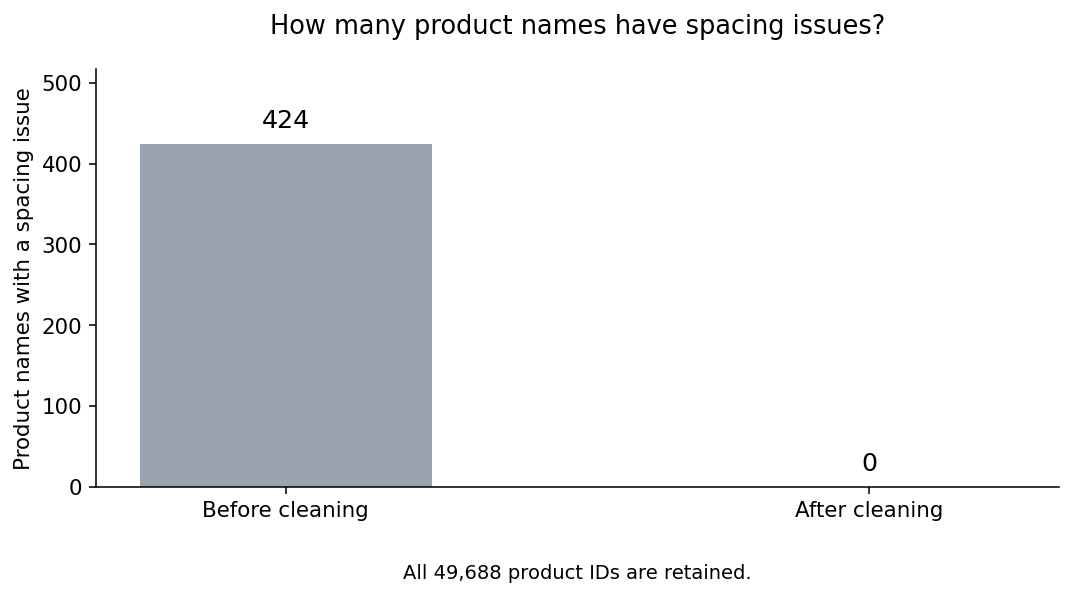

In [6]:
fig, ax = plt.subplots(figsize=(7.8,4.5))
bars = ax.bar(['Before cleaning','After cleaning'],[format_before,format_after],color=['#9AA3B0','#2D78B7'],width=.5)
ax.set_title('How many product names have spacing issues?',pad=18)
ax.set_ylabel('Product names with a spacing issue')
ax.set_ylim(0,max(1,format_before)*1.22)
ax.bar_label(bars,labels=[f'{format_before:,}',f'{format_after:,}'],padding=6,fontsize=13)
ax.text(.5,-.22,'All 49,688 product IDs are retained.',transform=ax.transAxes,ha='center',fontsize=10)
show_figure(fig,'01_spacing_before_after.png')

**Say in the presentation:** “We corrected spacing in 424 product names.
For example, two spaces in ‘Pizza for One Suprema Frozen Pizza’ became one.
After cleaning, no product names have the spacing issues we checked for.”

## Step 3 — Check missing values, NULLs, and valid zeros

**Question: Why is `days_since_prior_order` blank?**

A customer's first order has no previous order. All **206,209** blanks occur
on first orders. We keep this information missing. In pandas it is a numeric
missing value (`NaN`); during MySQL import it should become **SQL NULL**.
The CSV still contains an empty field because CSV has no native NULL type.

We do not fill those blanks with zero. A **0-day gap** is a real recorded value
and means another order occurred with no whole-day gap. First-order blanks
and real zero-day gaps have different meanings.

**Useful later:** MySQL can calculate `AVG(days_since_prior_order)` from known
gaps while ignoring NULLs. Filling first-order gaps with zero would lower the
average and give a misleading answer about repeat-order timing.

In [7]:
orders = clean['orders.csv']
interval_raw = raw['orders.csv'].days_since_prior_order
interval_blank = interval_raw.astype(str).str.strip().eq('')
# Parse the day-gap column; an empty field becomes a numeric missing value.
orders['days_since_prior_order'] = pd.to_numeric(interval_raw,errors='raise')
first = orders.order_number.eq(1)
missing = orders.days_since_prior_order.isna()
check('Unexpected missing intervals',(missing & ~first).sum(),'A later order should have its previous-order gap.')
check('First orders with a previous interval',(first & ~missing).sum(),'A first order has no previous order.')
check('Intervals outside 0-30 days',(orders.days_since_prior_order.notna() & ~orders.days_since_prior_order.between(0,30)).sum(),'Allowed day gaps are 0-30.')
missing_summary = pd.DataFrame({
    'Orders':['First orders','Later orders'],
    'Before: blank fields':[int((interval_blank & first).sum()),int((interval_blank & ~first).sum())],
    'After: missing values':[int((missing & first).sum()),int((missing & ~first).sum())],
    'Action':['Keep missing; import as SQL NULL','No missing values found']})
display(missing_summary)
missing_summary.to_csv(AUDIT_DIR/'simple_missing_before_after.csv',index=False)

example_rows = list(orders.index[first][:2]) + [orders.index[orders.days_since_prior_order.eq(0)][0]] + [orders.index[orders.days_since_prior_order.eq(15)][0]]
missing_examples = []
for i in example_rows:
    value = orders.at[i,'days_since_prior_order']
    missing_examples.append({'Order ID':int(orders.at[i,'order_id']), 'Order number':int(orders.at[i,'order_number']),
                             'Before':interval_raw.at[i] if interval_raw.at[i] != '' else '[blank]',
                             'After':'Missing → SQL NULL' if pd.isna(value) else f'{value:g} days',
                             'Why':'No previous order' if pd.isna(value) else 'A valid recorded gap; retain it'})
display(pd.DataFrame(missing_examples))
pd.DataFrame(missing_examples).to_csv(AUDIT_DIR/'simple_missing_examples.csv',index=False)

profile = pd.DataFrame(field_profiles)
display(profile[['file','column','missing_or_blank']].rename(columns={'file':'Table','column':'Column','missing_or_blank':'Blank cells'}))

Orders,Before: blank fields,After: missing values,Action
First orders,206209,206209,Keep missing; import as SQL NULL
Later orders,0,0,No missing values found


Order ID,Order number,Before,After,Why
2539329,1,[blank],Missing → SQL NULL,No previous order
2168274,1,[blank],Missing → SQL NULL,No previous order
2295261,9,0.0,0 days,A valid recorded gap; retain it
2398795,2,15.0,15 days,A valid recorded gap; retain it


Table,Column,Blank cells
products.csv,product_id,0
products.csv,product_name,0
products.csv,aisle_id,0
products.csv,department_id,0
aisles.csv,aisle_id,0
aisles.csv,aisle,0
departments.csv,department_id,0
departments.csv,department,0
orders.csv,order_id,0
orders.csv,user_id,0


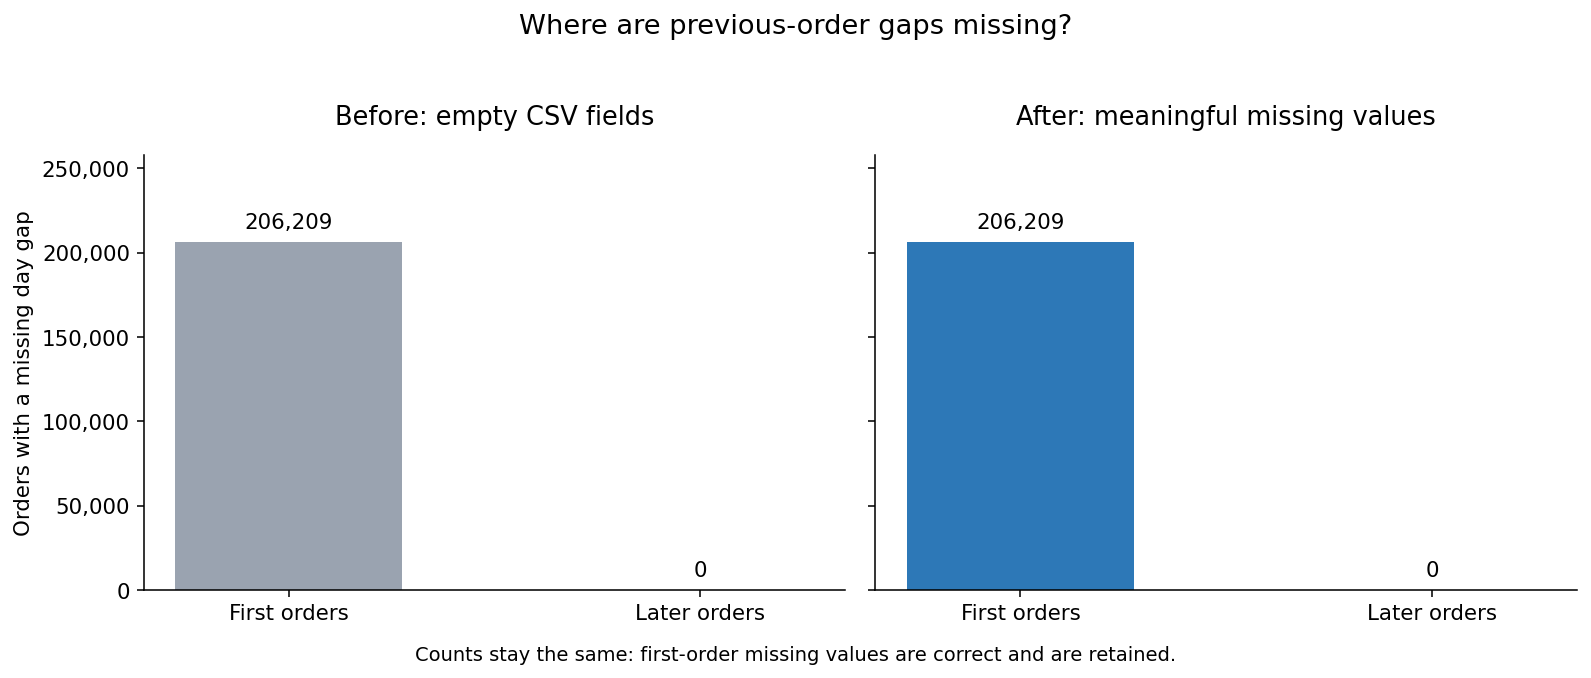

In [8]:
fig, axes = plt.subplots(1,2,figsize=(11.5,4.4),sharey=True)
missing_values = [[int((interval_blank & first).sum()),int((interval_blank & ~first).sum())],
                  [int((missing & first).sum()),int((missing & ~first).sum())]]
for ax,title,values,color in zip(axes,['Before: empty CSV fields','After: meaningful missing values'],missing_values,['#9AA3B0','#2D78B7']):
    bars=ax.bar(['First orders','Later orders'],values,color=color,width=.55)
    ax.set_title(title,pad=16)
    ax.set_ylim(0,max(1,int(missing.sum()))*1.25)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda n,p:f'{n:,.0f}'))
    ax.bar_label(bars,labels=[f'{v:,}' for v in values],padding=5)
axes[0].set_ylabel('Orders with a missing day gap')
fig.suptitle('Where are previous-order gaps missing?',fontsize=14,y=1.03)
fig.text(.5,-.02,'Counts stay the same: first-order missing values are correct and are retained.',ha='center',fontsize=10)
show_figure(fig,'02_missing_before_after.png')

In [9]:
catalog = products.merge(aisles,on='aisle_id',how='left',validate='many_to_one').merge(depts,on='department_id',how='left',validate='many_to_one')
special_labels = []
for field in ['aisle','department']:
    for label in ['missing','other']:
        count = int(catalog[field].eq(label).sum())
        if count:
            special_labels.append({'Column':field,'Source category':label,'Products':count,'Decision':'Retain the supplied category label'})
display(pd.DataFrame(special_labels))
valid_values = pd.DataFrame({'Value':['0-day gap','30-day gap','Midnight: hour 0'],
                            'Rows retained':[int(orders.days_since_prior_order.eq(0).sum()),int(orders.days_since_prior_order.eq(30).sum()),int(orders.order_hour_of_day.eq(0).sum())]})
display(valid_values)
print('The word "missing" is a supplied category label, not an empty CSV cell.')
print('The dataset caps day gaps at 30. A value of 30 is retained as supplied.')

The word "missing" is a supplied category label, not an empty CSV cell.
The dataset caps day gaps at 30. A value of 30 is retained as supplied.


Column,Source category,Products,Decision
aisle,missing,1258,Retain the supplied category label
aisle,other,548,Retain the supplied category label
department,missing,1258,Retain the supplied category label
department,other,548,Retain the supplied category label


Value,Rows retained
0-day gap,67755
30-day gap,369323
Midnight: hour 0,22758


**Say in the presentation:** “All blank day gaps belong to first orders, so
we kept them missing. A blank means there is no previous order; zero is a valid
day gap. This keeps later averages correct. The category named ‘missing’ is
also retained because it is a supplied label, not an empty cell.”

## Step 4 — Check duplicates and values

We distinguish three cases:

| Case | What it means | What we do |
| --- | --- | --- |
| Same complete row repeated | Possible accidental duplicate | Check the full table; none were found |
| Same entity ID repeated | Conflicting record identity | Check IDs and purchase keys; none were found |
| Same cleaned name, different IDs | Two catalog entries with the same label | Keep both IDs; a name alone does not prove duplication |

There are **37 matching-name groups** after spacing cleanup. They are logged
for review and kept separate. A product can also appear in many different
orders; those are real purchases, not duplicate rows.

**Useful later:** correct duplicate checks protect purchase counts and product
rankings from accidental double counting. Keeping distinct IDs protects valid
products. MySQL keys should use IDs; do not declare `product_name` unique.

In [10]:
collisions = products[products.product_name.duplicated(keep=False)].sort_values(['product_name','product_id'])
collision_groups = int(collisions.product_name.nunique())
collisions.to_csv(AUDIT_DIR/'matching_product_names_review.csv',index=False)
example_group = collisions.product_name.iloc[0]
same_name = collisions[collisions.product_name.eq(example_group)].copy()
same_name['Before name'] = same_name.product_id.map(raw['products.csv'].set_index('product_id').product_name)
same_name['Before name'] = same_name['Before name'].str.replace(' ','·',regex=False)
display(same_name[['product_id','Before name','product_name']].rename(columns={'product_id':'Product ID','product_name':'After name'}))
print('Both product IDs remain. Matching names are not enough evidence to delete a record.')
display(pd.DataFrame({'Measure':['Product records','Repeated product IDs','Matching-name groups'],
                      'Before':[len(raw['products.csv']),int(raw['products.csv'].product_id.duplicated().sum()),int(raw['products.csv'].product_name[raw['products.csv'].product_name.duplicated(False)].nunique())],
                      'After':[len(products),int(products.product_id.duplicated().sum()),collision_groups],
                      'Decision':['Retain every product','No repeated IDs found','Retain different IDs; log matching names']}))

Both product IDs remain. Matching names are not enough evidence to delete a record.


Product ID,Before name,After name
15964,100%·Prune··Juice,100% Prune Juice
28060,100%·Prune·Juice,100% Prune Juice


Measure,Before,After,Decision
Product records,49688,49688,Retain every product
Repeated product IDs,0,0,No repeated IDs found
Matching-name groups,0,37,Retain different IDs; log matching names


### Values should make sense

Hours must be 0–23; day-of-week codes must be 0–6; a known day gap must be
0–30; reorder flags must be 0 or 1; cart positions must start at 1.
Products must refer to existing aisles and departments. Purchases must refer
to existing orders and products.

**Useful later:** valid hours make the order-time chart reliable, and valid
references allow joins without silently losing purchases. Large basket sizes
are retained when their records are valid; a large number alone is not an error.

The two next cells perform the full checks. Their implementation can stay
collapsed during your presentation; the results below are the material to explain.

In [11]:
for filename,key in [('products.csv','product_id'),('aisles.csv','aisle_id'),('departments.csv','department_id'),('orders.csv','order_id'),('orders.csv','user_id')]:
    check(filename+'.'+key+': nonpositive IDs',(clean[filename][key]<=0).sum(),'Identifiers are positive.')
check('Invalid order numbers',(orders.order_number<1).sum(),'Sequence starts at 1.')
check('Invalid day-of-week codes',(~orders.order_dow.between(0,6)).sum(),'Codes are 0-6; weekday-name mapping is not assumed.')
check('Invalid hour codes',(~orders.order_hour_of_day.between(0,23)).sum(),'Hour is 0-23.')
check('Duplicate user/order-number pairs',orders.duplicated(['user_id','order_number']).sum(),'Sequence number is unique within each user.')
sequence=orders.groupby('user_id',observed=True).order_number.agg(['size','min','max'])
check('Users with missing/noncontiguous sequence numbers',((sequence['min']!=1)|(sequence['size']!=sequence['max'])).sum(),'With unique positive numbers, size=max and min=1 establish contiguous histories.')
user_max=orders.groupby('user_id',observed=True).order_number.transform('max')
is_final=orders.eval_set.isin(['train','test'])
check('Train/test orders outside final position',(is_final & orders.order_number.ne(user_max)).sum(),'Final release label occurs at the end of each user history.')
final_counts=orders.loc[is_final].groupby('user_id',observed=True).size().reindex(sequence.index,fill_value=0)
check('Users without exactly one final labelled order',(final_counts!=1).sum(),'Every supplied user has one train/test final order.')
check('Products with missing aisle references',(~products.aisle_id.isin(aisles.aisle_id)).sum(),'Every product aisle exists.')
check('Products with missing department references',(~products.department_id.isin(depts.department_id)).sum(),'Every product department exists.')
mapping=products[['aisle_id','department_id']].drop_duplicates().sort_values('aisle_id')
check('Aisles assigned multiple departments',(products.groupby('aisle_id').department_id.nunique()!=1).sum(),'Observed aisle_id -> department_id.')
check('Aisles missing from mapping',(~aisles.aisle_id.isin(mapping.aisle_id)).sum(),'All aisles have a verified department mapping.')
map_with_names=aisles.merge(mapping,on='aisle_id',validate='one_to_one')
map_with_names.to_csv(AUDIT_DIR/'aisle_department_mapping.csv',index=False)
reconstructed=products.drop(columns='department_id').merge(mapping,on='aisle_id',validate='many_to_one')[products.columns]
equal=reconstructed.sort_values('product_id').reset_index(drop=True).equals(products.sort_values('product_id').reset_index(drop=True))
check('Catalog reconstruction mismatches',0 if equal else 1,'Proposed decomposition must preserve every cleaned product field and row.')

print('Catalog IDs and references checked. Aisle-to-department mapping saved for Member 2.')

Catalog IDs and references checked. Aisle-to-department mapping saved for Member 2.


In [12]:
max_order,max_product=int(orders.order_id.max()),int(products.product_id.max())
product_base=max_product+1
max_sequence=int(orders.order_number.max())+1
order_exists=np.zeros(max_order+1,bool); product_exists=np.zeros(max_product+1,bool)
order_ids=orders.order_id.to_numpy(dtype=np.int64)
order_exists[order_ids]=True; product_exists[products.product_id.to_numpy(dtype=np.int64)]=True
eval_lookup=np.zeros(max_order+1,np.uint8)
eval_lookup[order_ids]=orders.eval_set.astype(str).map({'prior':1,'train':2,'test':3}).to_numpy(dtype=np.uint8)
user_lookup=np.zeros(max_order+1,np.uint32); sequence_lookup=np.zeros(max_order+1,np.uint16)
user_lookup[order_ids]=orders.user_id.to_numpy(dtype=np.uint32)
sequence_lookup[order_ids]=orders.order_number.to_numpy(dtype=np.uint16)
basket_counts=np.zeros(max_order+1,np.int32); max_cart=np.zeros(max_order+1,np.uint16)
observed_products=np.zeros(max_product+1,bool)
all_pair_keys,all_history_keys=[],[]
source_counts={}
for filename,expected_set in [('order_products__prior.csv',1),('order_products__train.csv',2)]:
    pair_chunks,complete_chunks,position_chunks,history_chunks=[],[],[],[]
    file_orders=np.zeros(max_order+1,bool); file_products=np.zeros(max_product+1,bool)
    rows=orphan_orders=orphan_products=wrong_set=bad_flags=bad_cart=0
    min_values={c:float('inf') for c in SCHEMAS[filename]}; max_values={c:float('-inf') for c in SCHEMAS[filename]}
    cart_values,reorder_values=set(),set()
    for chunk in pd.read_csv(RAW_DIR/filename,chunksize=CHUNK_SIZE,keep_default_na=False):
        for col in chunk.columns:
            # Stop on malformed values; never coerce missing required keys into zero.
            v=pd.to_numeric(chunk[col],errors='coerce')
            if v.isna().any() or v.mod(1).ne(0).any():
                raise ValueError(f'Inspect invalid required values in {filename}.{col}')
            chunk[col]=v
            min_values[col]=min(min_values[col],int(v.min())); max_values[col]=max(max_values[col],int(v.max()))
        oid=chunk.order_id.to_numpy(dtype=np.int64); pid=chunk.product_id.to_numpy(dtype=np.int64)
        cart=chunk.add_to_cart_order.to_numpy(dtype=np.int64); flag=chunk.reordered.to_numpy(dtype=np.int64)
        valid_o=(oid>0)&(oid<=max_order); valid_p=(pid>0)&(pid<=max_product)
        exists_o=np.zeros(len(chunk),bool); exists_p=np.zeros(len(chunk),bool)
        exists_o[valid_o]=order_exists[oid[valid_o]]; exists_p[valid_p]=product_exists[pid[valid_p]]
        orphan_orders+=int((~exists_o).sum()); orphan_products+=int((~exists_p).sum())
        wrong_set+=int((eval_lookup[oid[exists_o]]!=expected_set).sum())
        bad_flags+=int((~np.isin(flag,[0,1])).sum()); bad_cart+=int(((cart<1)|(cart>=32768)).sum())
        if not exists_o.all() or not exists_p.all() or bad_flags or bad_cart:
            raise ValueError('Invalid references/flags/positions require review before exact-key encoding and export.')
        pair=oid*product_base+pid
        pair_chunks.append(pair)
        # Fixed positional base is valid after bounds checks; these encodings are exact, not hashes.
        complete_chunks.append((pair*32768+cart)*2+flag)
        position_chunks.append(oid*32768+cart)
        history_chunks.append((user_lookup[oid].astype(np.int64)*product_base+pid)*max_sequence*2+sequence_lookup[oid].astype(np.int64)*2+flag)
        file_orders[oid]=True; file_products[pid]=True
        basket_counts+=np.bincount(oid,minlength=max_order+1).astype(np.int32)
        np.maximum.at(max_cart,oid,cart.astype(np.uint16))
        cart_values.update(np.unique(cart).tolist()); reorder_values.update(np.unique(flag).tolist())
        rows+=len(chunk)
        if rows%5_000_000==0:
            print(f'{filename}: {rows:,} rows parsed')
    pairs=np.concatenate(pair_chunks); complete=np.concatenate(complete_chunks); positions=np.concatenate(position_chunks)
    history=np.concatenate(history_chunks)
    del pair_chunks,complete_chunks,position_chunks,history_chunks
    pair_dups=duplicates_in_entire_array(pairs)
    row_dups=duplicates_in_entire_array(complete)
    position_dups=duplicates_in_entire_array(positions)
    del complete,positions
    for label,count,rule in [
      ('missing order references',orphan_orders,'All order references exist.'),
      ('missing product references',orphan_products,'All product references exist.'),
      ('wrong evaluation labels',wrong_set,'File membership matches Orders.eval_set.'),
      ('invalid reorder flags',bad_flags,'Flag is 0 or 1.'),
      ('invalid cart positions',bad_cart,'Cart positions are positive integers within encoding bounds.'),
      ('duplicate primary-key pairs',pair_dups,'Check complete file, not only chunks.'),
      ('identical duplicate records',row_dups,'Check all four fields jointly.'),
      ('duplicate cart positions',position_dups,'One position per order.'),
      ('labelled orders without supplied baskets',int(((eval_lookup==expected_set)&~file_orders).sum()),'Every prior/train order has its supplied basket.')]:
        check(filename+': '+label,count,rule,filename)
    for col in SCHEMAS[filename]:
        distinct=int(file_orders.sum()) if col=='order_id' else int(file_products.sum()) if col=='product_id' else len(cart_values) if col=='add_to_cart_order' else len(reorder_values)
        field_profiles.append({'file':filename,'column':col,'missing_or_blank':0,'distinct_nonblank':distinct,'raw_dtype':'validated integer'})
    source_counts[filename]=rows
    inventory.append({'file':filename,'rows':rows,'columns':4})
    all_pair_keys.append(pairs); all_history_keys.append(history)
    observed_products|=file_products
    print(f'{filename}: {rows:,} rows checked; duplicate pairs={pair_dups:,}')
combined_pairs=np.concatenate(all_pair_keys); combined_history=np.concatenate(all_history_keys)
del all_pair_keys,all_history_keys
union_duplicates=duplicates_in_entire_array(combined_pairs)
check('Prior/train union duplicate purchase keys',union_duplicates,'Combined link-table key must stay unique.')
del combined_pairs
combined_history.sort()
history_group=combined_history//(max_sequence*2)
first_occurrence=np.empty(len(history_group),bool)
first_occurrence[0]=True; first_occurrence[1:]=history_group[1:]!=history_group[:-1]
reorder_mismatches=int(np.count_nonzero((combined_history%2).astype(bool)!=~first_occurrence))
check('Reordered flags disagreeing with complete user-product history',reorder_mismatches,'First occurrence is 0; later occurrences are 1.')
del combined_history,history_group,first_occurrence
observed_baskets=basket_counts>0
check('Noncontiguous cart positions',np.count_nonzero(observed_baskets&(basket_counts!=max_cart)),'Positive unique positions must cover 1 to basket line count.')
check('Test orders with supplied baskets',np.count_nonzero((eval_lookup==3)&observed_baskets),'Test basket contents are withheld in this release.')
audit_checks=pd.DataFrame(checks)
audit_checks.to_csv(AUDIT_DIR/'validation_checks.csv',index=False)
pd.DataFrame(inventory).to_csv(AUDIT_DIR/'source_file_inventory.csv',index=False)
pd.DataFrame(field_profiles).to_csv(AUDIT_DIR/'source_column_profile.csv',index=False)


print('Reorder-history mismatches:',reorder_mismatches)
print('Purchase rows checked:',sum(source_counts.values()))

order_products__prior.csv: 5,000,000 rows parsed
order_products__prior.csv: 10,000,000 rows parsed
order_products__prior.csv: 15,000,000 rows parsed
order_products__prior.csv: 20,000,000 rows parsed
order_products__prior.csv: 25,000,000 rows parsed
order_products__prior.csv: 30,000,000 rows parsed
order_products__prior.csv: 32,434,489 rows checked; duplicate pairs=0
order_products__train.csv: 1,384,617 rows checked; duplicate pairs=0
Reorder-history mismatches: 0
Purchase rows checked: 33819106


In [13]:
duplicate_summary=[]
for filename in KEYS:
    duplicate_summary.append({'Table':filename,'Rows checked':len(raw[filename]),
                              'Repeated complete rows':int(raw[filename].duplicated().sum()),
                              'Repeated keys':int(raw[filename].duplicated(KEYS[filename]).sum()),'Action':'Retain all records'})
for filename in ['order_products__prior.csv','order_products__train.csv']:
    row_issue = int(audit_checks.loc[audit_checks['check'].eq(filename+': identical duplicate records'),'issue_count'].iloc[0])
    key_issue = int(audit_checks.loc[audit_checks['check'].eq(filename+': duplicate primary-key pairs'),'issue_count'].iloc[0])
    duplicate_summary.append({'Table':filename,'Rows checked':source_counts[filename],
                              'Repeated complete rows':row_issue,'Repeated keys':key_issue,'Action':'Retain all records'})
duplicate_summary = pd.DataFrame(duplicate_summary)
duplicate_summary.to_csv(AUDIT_DIR/'simple_duplicate_checks.csv',index=False)
display(duplicate_summary)
print('The combined prior/train purchase key was checked too. Repeated keys:',union_duplicates)

value_summary = pd.DataFrame([
    {'Column':'Order hour','Allowed values':'0 to 23','Observed values':f'{orders.order_hour_of_day.min()} to {orders.order_hour_of_day.max()}', 'Invalid values':int((~orders.order_hour_of_day.between(0,23)).sum()),'Useful later':'Reliable chart by hour'},
    {'Column':'Day-of-week code','Allowed values':'0 to 6','Observed values':f'{orders.order_dow.min()} to {orders.order_dow.max()}', 'Invalid values':int((~orders.order_dow.between(0,6)).sum()),'Useful later':'Reliable grouping by day code'},
    {'Column':'Known previous-order gap','Allowed values':'0 to 30 days','Observed values':f'{orders.days_since_prior_order.min():g} to {orders.days_since_prior_order.max():g}', 'Invalid values':int((orders.days_since_prior_order.notna() & ~orders.days_since_prior_order.between(0,30)).sum()),'Useful later':'Correct repeat-order timing'},
    {'Column':'Purchase reorder flag','Allowed values':'0 or 1','Observed values':'0 and 1', 'Invalid values':int(audit_checks.loc[audit_checks['check'].str.endswith(': invalid reorder flags'),'issue_count'].sum()),'Useful later':'Correct reorder rates'},
    {'Column':'Purchase cart position','Allowed values':'Positive whole numbers, in order','Observed values':f'1 to {int(max_cart.max())}', 'Invalid values':int(audit_checks.loc[audit_checks['check'].str.endswith(': invalid cart positions'),'issue_count'].sum()),'Useful later':'Trustworthy basket-size counts'}])
value_summary.to_csv(AUDIT_DIR/'simple_value_checks.csv',index=False)
display(value_summary)
profile = pd.DataFrame(field_profiles)
print('Unexpected blanks in other columns:',int(profile.loc[profile.column.ne('days_since_prior_order'),'missing_or_blank'].sum()))
display(pd.DataFrame(inventory).rename(columns={'file':'Source file','rows':'Rows processed','columns':'Columns'}))
basket_sizes = basket_counts[observed_baskets]
unused = products[~observed_products[products.product_id.to_numpy(dtype=np.int64)]]
unused.to_csv(AUDIT_DIR/'unused_catalog_products_retained.csv',index=False)
print('Largest valid supplied basket:',int(basket_sizes.max()),'distinct products. Retained.')
print('Catalog products not observed in supplied purchases:',len(unused),'. Retained.')

The combined prior/train purchase key was checked too. Repeated keys: 0
Unexpected blanks in other columns: 0
Largest valid supplied basket: 145 distinct products. Retained.
Catalog products not observed in supplied purchases: 3 . Retained.


Table,Rows checked,Repeated complete rows,Repeated keys,Action
products.csv,49688,0,0,Retain all records
aisles.csv,134,0,0,Retain all records
departments.csv,21,0,0,Retain all records
orders.csv,3421083,0,0,Retain all records
order_products__prior.csv,32434489,0,0,Retain all records
order_products__train.csv,1384617,0,0,Retain all records


Column,Allowed values,Observed values,Invalid values,Useful later
Order hour,0 to 23,0 to 23,0,Reliable chart by hour
Day-of-week code,0 to 6,0 to 6,0,Reliable grouping by day code
Known previous-order gap,0 to 30 days,0 to 30,0,Correct repeat-order timing
Purchase reorder flag,0 or 1,0 and 1,0,Correct reorder rates
Purchase cart position,"Positive whole numbers, in order",1 to 145,0,Trustworthy basket-size counts


Source file,Rows processed,Columns
products.csv,49688,4
aisles.csv,134,2
departments.csv,21,2
orders.csv,3421083,7
order_products__prior.csv,32434489,4
order_products__train.csv,1384617,4


**Say in the presentation:** “We checked full-row duplicates and repeated
keys in all six files, including the complete purchase files. There were no
accidental duplicates. We also checked missing values, valid ranges, and table
references. Similar names with different IDs were kept, so valid products and
purchases are not lost.”

## Step 5 — Before/after summary, simple charts, and team files

The summary distinguishes **changes we made** from **valid data we kept**.
Keeping a meaningful NULL or a valid zero is an evidence-based cleaning decision.
We do not need to change every column to show useful preparation work.

In [14]:
before_after = pd.DataFrame([
    {'Cleaning topic':'Product-name spacing','Before':'424 names with spacing issues','After':'0 names with those spacing issues','What we did':'Trim ends, replace no-break spaces, use one space','Useful later':'Consistent text search and readable labels'},
    {'Cleaning topic':'First-order missing gaps','Before':f'{int(interval_blank.sum()):,} empty fields','After':f'{int(missing.sum()):,} meaningful missing values','What we did':'Keep missing; import as SQL NULL','Useful later':'Avoid false zero-day gaps and biased averages'},
    {'Cleaning topic':'Unexpected missing values','Before':'0 in the other supplied columns','After':'0','What we did':'Check all columns; no fill needed','Useful later':'Required IDs and flags are available'},
    {'Cleaning topic':'Duplicate rows and keys','Before':'0 accidental duplicates','After':'0','What we did':'Check complete files and their union; retain rows','Useful later':'Purchase counts are not inflated'},
    {'Cleaning topic':'Matching names, different IDs','Before':'0 matching-name groups','After':f'{collision_groups} groups after spacing cleanup','What we did':'Retain all IDs; save a review list','Useful later':'Do not delete valid catalog entries'},
    {'Cleaning topic':'Invalid value ranges','Before':'0 invalid checked values','After':'0','What we did':'Validate hours, gaps, flags, and cart positions','Useful later':'Trustworthy grouping and calculations'},
    {'Cleaning topic':'Valid zeros and capped gaps','Before':'Valid 0 and 30 values','After':'Same values retained','What we did':'Interpret values using column meaning','Useful later':'Preserve real timing and midnight orders'},
    {'Cleaning topic':'Total source records','Before':f'{len(orders):,} orders; {sum(source_counts.values()):,} purchases','After':f'{len(orders):,} orders; {sum(source_counts.values()):,} purchases','What we did':'No records removed','Useful later':'Team works with the complete supplied dataset'}])
before_after.to_csv(AUDIT_DIR/'before_after_transformations.csv',index=False)
before_after.to_csv(AUDIT_DIR/'cleaning_decisions.csv',index=False)
display(before_after)

Cleaning topic,Before,After,What we did,Useful later
Product-name spacing,424 names with spacing issues,0 names with those spacing issues,"Trim ends, replace no-break spaces, use one space",Consistent text search and readable labels
First-order missing gaps,"206,209 empty fields","206,209 meaningful missing values",Keep missing; import as SQL NULL,Avoid false zero-day gaps and biased averages
Unexpected missing values,0 in the other supplied columns,0,Check all columns; no fill needed,Required IDs and flags are available
Duplicate rows and keys,0 accidental duplicates,0,Check complete files and their union; retain rows,Purchase counts are not inflated
"Matching names, different IDs",0 matching-name groups,37 groups after spacing cleanup,Retain all IDs; save a review list,Do not delete valid catalog entries
Invalid value ranges,0 invalid checked values,0,"Validate hours, gaps, flags, and cart positions",Trustworthy grouping and calculations
Valid zeros and capped gaps,Valid 0 and 30 values,Same values retained,Interpret values using column meaning,Preserve real timing and midnight orders
Total source records,"3,421,083 orders; 33,819,106 purchases","3,421,083 orders; 33,819,106 purchases",No records removed,Team works with the complete supplied dataset


### Export the cleaned data and verify it

Write the four catalog/order files and combine the two validated purchase files
into `order_products.csv` for the team. **Combining files is handoff preparation,
not a cleaning correction.** All purchase values and records are preserved.

Member 2 uses the cleaned catalog and its aisle–department mapping for the
database design. Member 3 imports the CSVs, converts empty day-gap fields to
SQL NULL, and verifies the database. Your teammates can find import notes in
the ZIP's README.

In [15]:
audit_checks = pd.DataFrame(checks)
if audit_checks.status.ne('PASS').any():
    display(audit_checks[audit_checks.status.ne('PASS')])
    raise ValueError('Review these findings before exporting the team data.')
for filename,frame in clean.items():
    frame.to_csv(TABLE_DIR/filename,index=False,encoding='utf-8',na_rep='')
merged_path = TABLE_DIR/'order_products.csv'
temporary = merged_path.with_suffix('.csv.tmp')
with temporary.open('wb') as output:
    for i,filename in enumerate(['order_products__prior.csv','order_products__train.csv']):
        with (RAW_DIR/filename).open('rb') as source:
            header = source.readline()
            if i == 0:
                output.write(header)
            shutil.copyfileobj(source,output,length=4*1024*1024)
        with (RAW_DIR/filename).open('rb') as source:
            source.seek(-1,2)
            if source.read(1) != b'\n':
                output.write(b'\n')
temporary.replace(merged_path)
output_counts = {filename:len(frame) for filename,frame in clean.items()}
output_counts['order_products.csv'] = sum(source_counts.values())
print('Five cleaned CSVs exported. Verifying the actual saved files next.')

Five cleaned CSVs exported. Verifying the actual saved files next.


In [16]:
reloaded = {}
for filename, expected in clean.items():
    numeric_types = {c:str(expected[c].dtype) for c in expected.columns if c not in TEXT}
    loaded = pd.read_csv(TABLE_DIR/filename,keep_default_na=False,
                         na_values={'days_since_prior_order':['']},dtype=numeric_types)
    reloaded[filename] = loaded
    for column in expected:
        check('Export '+filename+'.'+column+': changed/lost values',0 if loaded[column].equals(expected[column]) else 1,
              'Saved data must match cleaned values and missingness.')
clean_basket_counts = np.zeros_like(basket_counts)
merged_rows = 0
for chunk in pd.read_csv(merged_path,chunksize=CHUNK_SIZE,
                         dtype={'order_id':'uint32','product_id':'uint32','add_to_cart_order':'uint16','reordered':'uint8'}):
    merged_rows += len(chunk)
    clean_basket_counts += np.bincount(chunk.order_id.to_numpy(dtype=np.int64),minlength=len(basket_counts)).astype(np.int32)
check('Export merged purchase row count',abs(merged_rows-sum(source_counts.values())),'Keep every purchase record.')
check('Export changed basket sizes',int(np.count_nonzero(clean_basket_counts!=basket_counts)),'Every supplied basket size must remain unchanged.')
expected_digest = hashlib.sha256()
for i,filename in enumerate(['order_products__prior.csv','order_products__train.csv']):
    with (RAW_DIR/filename).open('rb') as source:
        header=source.readline()
        if i==0:
            expected_digest.update(header)
        for block in iter(lambda:source.read(4*1024*1024),b''):
            expected_digest.update(block)
    with (RAW_DIR/filename).open('rb') as source:
        source.seek(-1,2)
        if source.read(1)!=b'\n':
            expected_digest.update(b'\n')
check('Export merged purchase byte-preservation check',0 if sha256(merged_path)==expected_digest.hexdigest() else 1,
      'Saved purchases equal the original values, with one header.')
for row in manifest.itertuples(index=False):
    check('Original unchanged: '+row.file,0 if sha256(RAW_DIR/row.file)==row.sha256 else 1,'Original source files must stay unchanged.')
audit_checks = pd.DataFrame(checks)
assert audit_checks.status.eq('PASS').all(), 'Investigate failed checks before sharing.'
audit_checks.to_csv(AUDIT_DIR/'validation_checks.csv',index=False)
output_manifest = pd.DataFrame([{'file':filename,'rows':rows,'bytes':(TABLE_DIR/filename).stat().st_size,
                                'sha256':sha256(TABLE_DIR/filename)} for filename,rows in output_counts.items()])
output_manifest.to_csv(AUDIT_DIR/'cleaned_file_manifest.csv',index=False)
contract = {filename:{col:str(dtype) for col,dtype in frame.dtypes.items()} for filename,frame in clean.items()}
contract['order_products.csv']={'order_id':'uint32','product_id':'uint32','add_to_cart_order':'uint16','reordered':'uint8'}
(AUDIT_DIR/'processing_dtype_contract.json').write_text(json.dumps(contract,indent=2))
pd.DataFrame([{'file':filename,'column':col,'before_dtype':str(raw[filename][col].dtype),'after_dtype':str(frame[col].dtype)}
              for filename,frame in clean.items() for col in frame]).to_csv(AUDIT_DIR/'dtype_before_after.csv',index=False)
display(output_manifest[['file','rows']].rename(columns={'file':'Cleaned file','rows':'Rows retained'}))
print('Passed checks:',len(audit_checks),'| Records deleted: 0')

Passed checks: 86 | Records deleted: 0


Cleaned file,Rows retained
products.csv,49688
aisles.csv,134
departments.csv,21
orders.csv,3421083
order_products.csv,33819106


### Simple chart 1 — At which hours are the most orders placed?

A bar shows the number of orders at that hour, using **all 3,421,083 orders**.
The before/after charts use the original and the re-read cleaned Orders files.
Matching charts show that name cleaning and correct NULL handling preserve
the ordering pattern. This is a distribution of **order counts**, not revenue.

**Useful later:** Member 1 can use a simple SQL `GROUP BY order_hour_of_day`
query. The peak hour describes customer activity in the supplied records.

Peak hour: 10:00, with 288,418 orders (8.4% of all supplied orders).


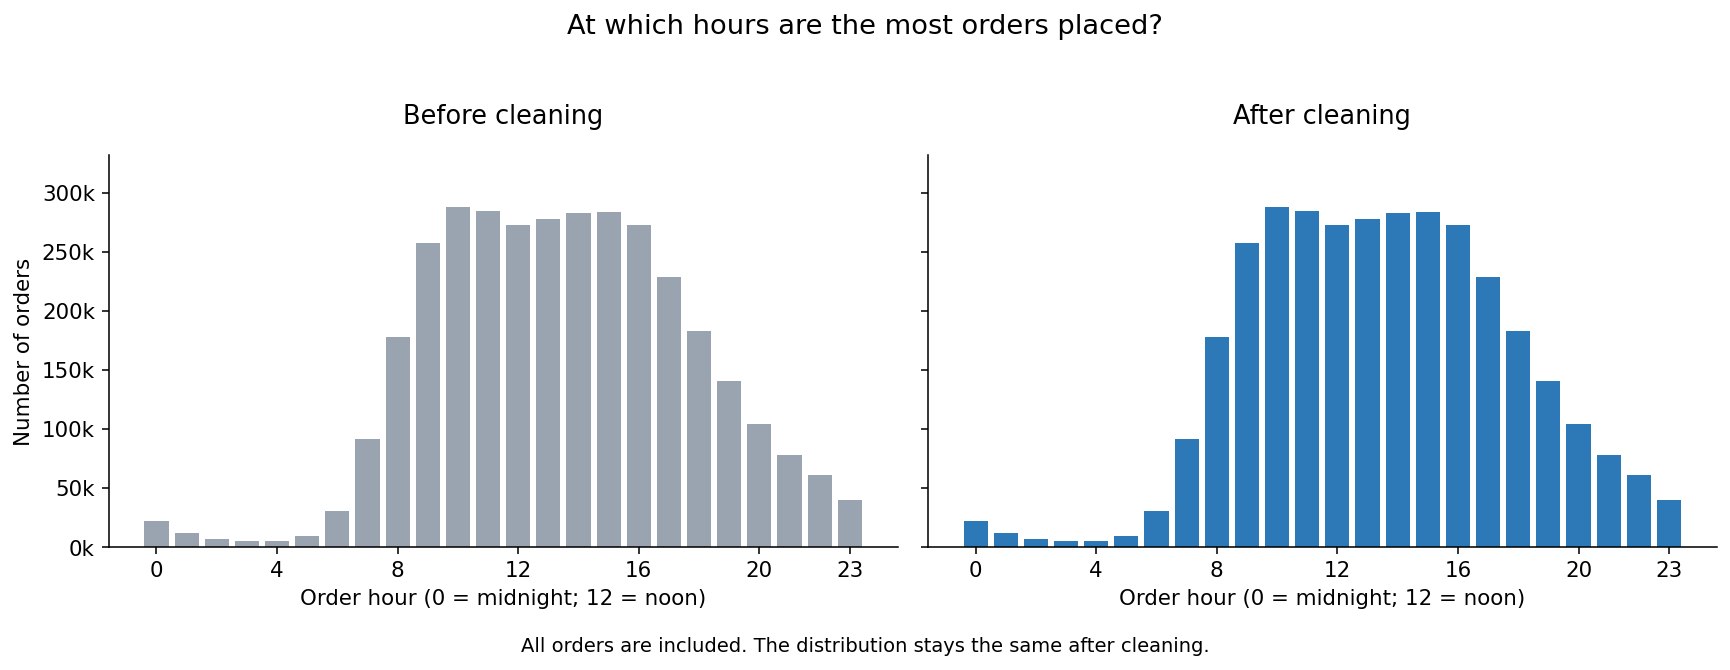

In [17]:
hours = np.arange(24)
hour_before = raw['orders.csv'].order_hour_of_day.value_counts().reindex(hours,fill_value=0)
hour_after = reloaded['orders.csv'].order_hour_of_day.value_counts().reindex(hours,fill_value=0)
assert hour_before.equals(hour_after)
hour_distribution = pd.DataFrame({'Hour':hours,'Before orders':hour_before.values,'After orders':hour_after.values})
hour_distribution.to_csv(AUDIT_DIR/'distribution_orders_by_hour.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(12.5,4.3),sharey=True)
for ax,title,values,color in zip(axes,['Before cleaning','After cleaning'],[hour_before,hour_after],['#9AA3B0','#2D78B7']):
    ax.bar(hours,values,color=color,width=.8)
    ax.set_title(title,pad=16)
    ax.set_xlabel('Order hour (0 = midnight; 12 = noon)')
    ax.set_xticks([0,4,8,12,16,20,23])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda n,p:f'{n/1000:,.0f}k'))
    ax.set_ylim(0,hour_before.max()*1.15)
axes[0].set_ylabel('Number of orders')
fig.suptitle('At which hours are the most orders placed?',fontsize=14,y=1.03)
fig.text(.5,-.03,'All orders are included. The distribution stays the same after cleaning.',ha='center',fontsize=10)
show_figure(fig,'03_orders_by_hour_before_after.png')
peak_hour=int(hour_after.idxmax()); peak_hour_count=int(hour_after.max())
print(f'Peak hour: {peak_hour}:00, with {peak_hour_count:,} orders ({100*peak_hour_count/len(orders):.1f}% of all supplied orders).')

### Simple chart 2 — Which departments have the most catalog products?

Count distinct product IDs in each department and show the largest eight.
This chart describes the **catalog**, using all **49,688 products** to calculate
the counts. It does not measure sales or purchased quantities. Original and
cleaned files give the same counts because product IDs and categories are kept.

**Useful later:** valid product-to-department references make SQL joins work,
and consistent category labels make the result easy to read.

Largest catalog department: personal care, with 6,563 distinct products.


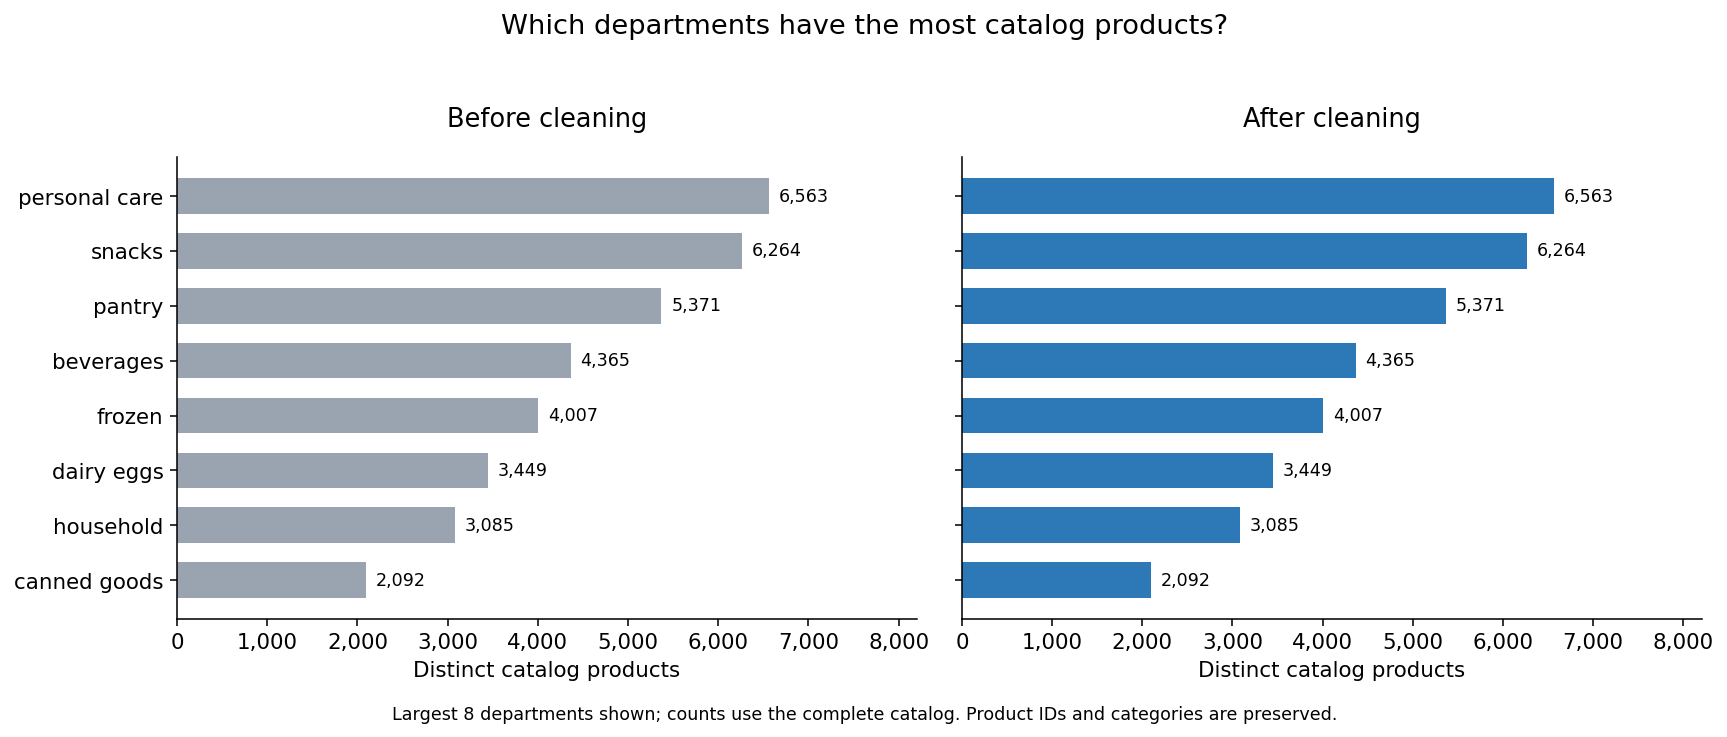

In [18]:
department_before = raw['products.csv'].groupby('department_id').product_id.nunique()
department_after = reloaded['products.csv'].groupby('department_id').product_id.nunique()
assert department_before.equals(department_after)
department_distribution = pd.DataFrame({'department_id':department_after.index,
                                       'Before products':department_before.values,'After products':department_after.values})
department_distribution = department_distribution.merge(reloaded['departments.csv'],on='department_id').sort_values('After products',ascending=False)
department_distribution.to_csv(AUDIT_DIR/'distribution_catalog_by_department.csv',index=False)
top_departments=department_distribution.head(8).iloc[::-1]
fig,axes=plt.subplots(1,2,figsize=(12.5,4.8),sharey=True)
for ax,title,col,color in zip(axes,['Before cleaning','After cleaning'],['Before products','After products'],['#9AA3B0','#2D78B7']):
    bars=ax.barh(top_departments.department,top_departments[col],color=color,height=.65)
    ax.set_title(title,pad=16)
    ax.set_xlabel('Distinct catalog products')
    ax.set_xlim(0,top_departments[col].max()*1.25)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda n,p:f'{n:,.0f}'))
    ax.bar_label(bars,labels=[f'{n:,}' for n in top_departments[col]],padding=5,fontsize=9)
fig.suptitle('Which departments have the most catalog products?',fontsize=14,y=1.03)
fig.text(.5,-.02,'Largest 8 departments shown; counts use the complete catalog. Product IDs and categories are preserved.',ha='center',fontsize=9)
show_figure(fig,'04_department_products_before_after.png')
largest_department=department_distribution.iloc[0]
print(f'Largest catalog department: {largest_department.department}, with {largest_department["After products"]:,} distinct products.')

### Simple chart 3 — How many different products are in a typical basket?

Use all **33,819,106 purchase lines** from prior and train orders. Each line is
one distinct product in an order; it does not give quantity or price. Group
baskets into easy ranges such as 1–5 and 6–10 different products.

The chart includes every order with a supplied basket. The **75,000 test
orders** have withheld contents and are excluded from basket-size calculations;
they must not be counted as empty baskets.

**Useful later:** duplicate purchase keys would inflate basket sizes, and
missing references could lose items in a join. The full checks make this chart
and later SQL basket summaries reliable.

Observed baskets: 3,346,083. Median: 8 different products. Most common range: 1–5.
These are distinct product counts, not purchased quantities.


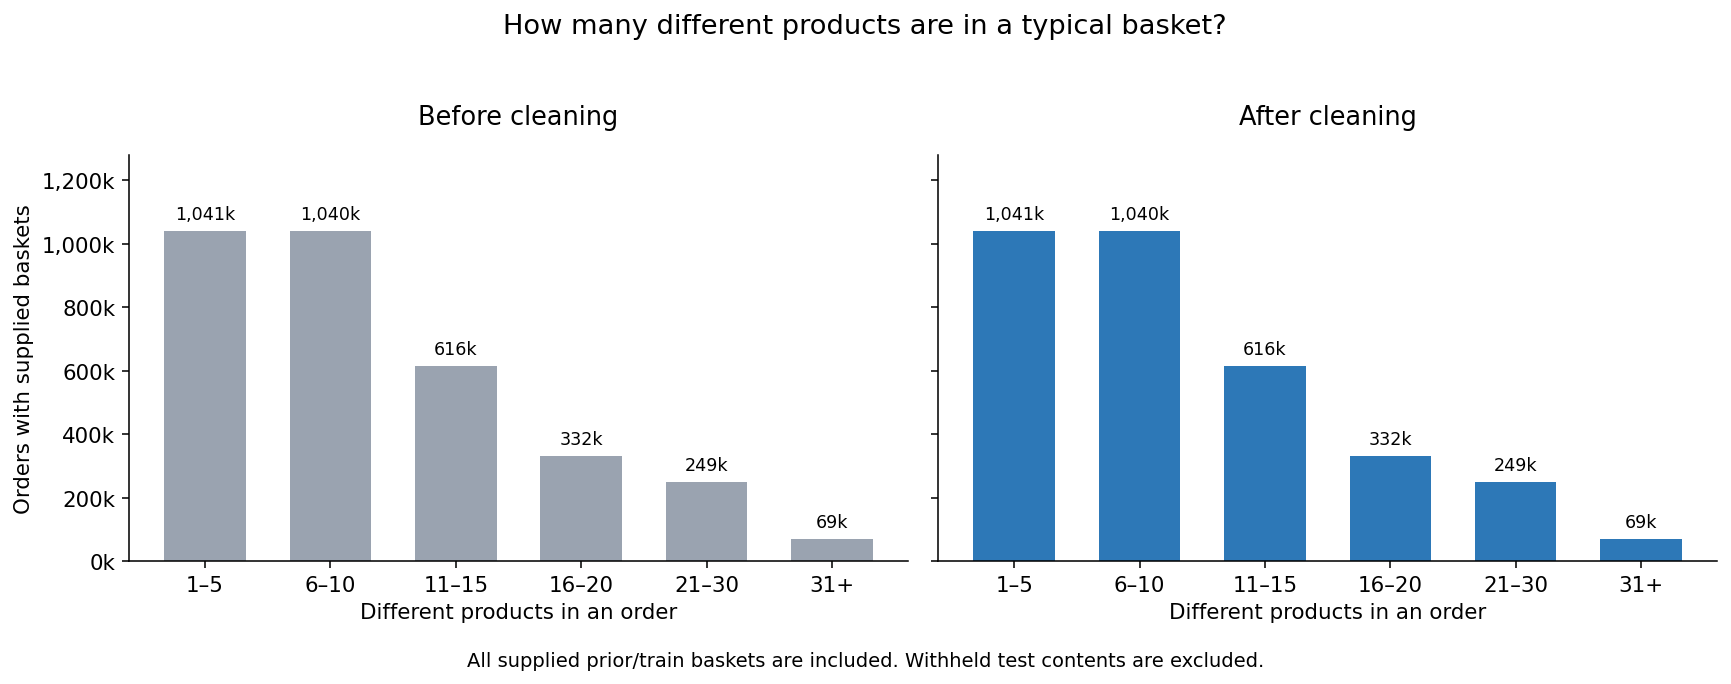

In [19]:
clean_sizes=clean_basket_counts[clean_basket_counts>0]
edges=[0,5,10,15,20,30,np.inf]
basket_labels=['1–5','6–10','11–15','16–20','21–30','31+']
size_before=pd.cut(basket_sizes,bins=edges,labels=basket_labels).value_counts().reindex(basket_labels,fill_value=0)
size_after=pd.cut(clean_sizes,bins=edges,labels=basket_labels).value_counts().reindex(basket_labels,fill_value=0)
assert size_before.equals(size_after)
basket_distribution=pd.DataFrame({'Different products':basket_labels,'Before orders':size_before.values,'After orders':size_after.values})
basket_distribution.to_csv(AUDIT_DIR/'distribution_basket_size.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(12.5,4.4),sharey=True)
for ax,title,values,color in zip(axes,['Before cleaning','After cleaning'],[size_before,size_after],['#9AA3B0','#2D78B7']):
    bars=ax.bar(basket_labels,values,color=color,width=.65)
    ax.set_title(title,pad=16)
    ax.set_xlabel('Different products in an order')
    ax.set_ylim(0,size_before.max()*1.23)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda n,p:f'{n/1000:,.0f}k'))
    ax.bar_label(bars,labels=[f'{n/1000:,.0f}k' for n in values],padding=4,fontsize=9)
axes[0].set_ylabel('Orders with supplied baskets')
fig.suptitle('How many different products are in a typical basket?',fontsize=14,y=1.03)
fig.text(.5,-.03,'All supplied prior/train baskets are included. Withheld test contents are excluded.',ha='center',fontsize=10)
show_figure(fig,'05_basket_size_before_after.png')
median_basket=int(np.median(clean_sizes))
largest_group=str(size_after.idxmax())
print(f'Observed baskets: {len(clean_sizes):,}. Median: {median_basket} different products. Most common range: {largest_group}.')
print('These are distinct product counts, not purchased quantities.')

### What to present and what to send

Present the real spacing examples, the missing-value explanation, the duplicate
decision, and one or two simple distribution charts. The complete reports and
all five PNG figures are in the cleaned-data ZIP. A short slide outline and
speaking script are generated below.

The data charts intentionally match before and after: the purpose of these
corrections is to improve data quality while preserving valid buying patterns.
Only the product-name spacing-issue count falls from 424 to zero.

In [20]:
summary={'source_rows':{row['file']:row['rows'] for row in inventory},'cleaned_rows':output_counts,
         'users':int(orders.user_id.nunique()),'product_labels_standardized':format_before,
         'expected_missing_intervals_retained':int(missing.sum()),'matching_name_groups_retained':collision_groups,
         'passed_checks':len(audit_checks),'rows_removed':0,'observed_baskets':len(clean_sizes),
         'median_basket_distinct_products':median_basket,'largest_basket_distinct_products':int(clean_sizes.max()),
         'withheld_test_orders':int(orders.eval_set.eq('test').sum()),'peak_order_hour':peak_hour,
         'peak_hour_orders':peak_hour_count,'most_common_basket_range':largest_group,
         'versions':{'pandas':pd.__version__,'numpy':np.__version__,'matplotlib':matplotlib.__version__}}
(AUDIT_DIR/'run_summary.json').write_text(json.dumps(summary,indent=2))

notes=f'''# Member 1 — simple cleaning presentation

## Slide 1: What is the data?
- {len(orders):,} orders from {summary['users']:,} customers.
- {len(products):,} catalog products and {sum(source_counts.values()):,} supplied purchase lines.
- We processed all six source files, not a sample.

## Slide 2: One real correction — spaces in product names
- We standardized spacing in {format_before} names and kept every product ID.
- Show figures/01_spacing_before_after.png: spacing issues fall from 424 to 0.

| Real example | Before | After | Why useful later |
| --- | --- | --- | --- |
| Product 18 | `Pizza for One Suprema  Frozen Pizza` | `Pizza for One Suprema Frozen Pizza` | Consistent text lookup and display |
| Product 7484 | `Southern Butter Pecan[NBSP]Gelato` | `Southern Butter Pecan Gelato` | Replace an unusual space with a normal space |
| Product 44990 | `Complete Mint Flavor Satin Floss[NBSP]` | `Complete Mint Flavor Satin Floss` | Remove an invisible space at the end |

`[NBSP]` marks an unusual no-break space. These are real source records.

## Slide 3: Missing values, duplicates, and valid values
- All {int(missing.sum()):,} blank previous-order gaps belong to first orders. Keep them missing and import as SQL NULL.
- A first order has no earlier order; zero would mean a recorded zero-day gap.
- {int(orders.days_since_prior_order.eq(0).sum()):,} actual zero-day gaps are retained.
- Full-row and key checks found zero accidental duplicates across the supplied files and combined purchases.
- {collision_groups} groups have the same cleaned name but different IDs. Keep them separate; product names are not unique keys.
- Valid hours, categories, and purchase references support correct GROUP BY calculations and joins.

Show figures/02_missing_before_after.png. The missing-value count stays the same because those blanks are meaningful.

## Slide 4: Easy dataset patterns and team handoff
Choose one or two of these charts:
- **When are most orders placed?** The peak is {peak_hour}:00 with {peak_hour_count:,} orders. Use figures/03_orders_by_hour_before_after.png.
- **Which departments have the most catalog products?** {largest_department.department} has {largest_department['After products']:,}. Use figures/04_department_products_before_after.png. This measures catalog variety, not popularity or sales.
- **How many different products are in a typical basket?** The median is {median_basket}; the most common range is {largest_group}. Use figures/05_basket_size_before_after.png.
- These distributions match before and after because valid records and buying patterns are preserved.
- Send the cleaned ZIP to the team: five CSVs, examples, charts, and checks. No records were removed.

## How each cleaning decision helps the next steps

| Cleaning decision | How it helps |
| --- | --- |
| Fix spaces in labels | Consistent text search, readable query output, and readable charts |
| Keep first-order blanks as NULL | Correct averages of known gaps; no invented zero-day orders |
| Check full rows and ID/purchase keys | Avoid inflated order, product, and basket counts |
| Keep different IDs with matching names | Preserve valid products and purchases; join on IDs |
| Validate hours, flags, and gaps | Trustworthy hourly groups, reorder rates, and repeat-order timing |
| Validate references | MySQL joins connect purchases to real orders and products |
| Retain valid zeros and large baskets | Preserve actual customer behavior |

## Suggested 90-second explanation
We prepared the complete Instacart dataset for our team's database work. First, we checked spaces, missing values, duplicates, and invalid values. We found a real formatting issue in 424 product names. For example, two spaces inside a product name became one normal space. This makes names consistent while keeping all IDs. Next, all 206,209 missing previous-order gaps belonged to first orders. We kept them missing because a first order has no previous order. Filling them with zero would distort later averages. We also checked complete duplicate rows and repeated keys across all files. There were no accidental duplicates. Some names matched after cleaning, but their product IDs differed, so we kept those entries. Finally, we verified allowed values and relationships, created simple charts, and exported the files. The before-and-after distributions are the same because all valid orders and purchases are preserved.

## Questions you can answer simply
- **Why did the missing count not decrease?** First-order gaps are correctly missing. Removing or filling them would change their meaning.
- **Why did matching names increase?** Spacing differences were removed. Different IDs still identify separate records.
- **Why not replace every unusual value?** A large basket or zero-day gap can be valid. We checked its context before deciding.
- **Why do the data charts match?** Cleaning labels and preserving correct NULLs should not remove valid activity.
- **Are these sales or quantities?** No. The data contains product lines, not prices or purchased quantities.
- **How many rows were deleted?** Zero; there was no evidence that deletion was needed.
'''
(OUT_DIR/'Member1_Presentation_Notes.md').write_text(notes,encoding='utf-8')
print('Presentation notes generated: four slides, a 90-second script, and simple Q&A.')

Presentation notes generated: four slides, a 90-second script, and simple Q&A.


In [21]:
readme=f'''# Instacart cleaned-data handoff — simple cleaning version

## Files to use
| File | Rows |
| --- | ---: |
| tables/products.csv | {len(products):,} |
| tables/aisles.csv | {len(aisles):,} |
| tables/departments.csv | {len(depts):,} |
| tables/orders.csv | {len(orders):,} |
| tables/order_products.csv | {sum(source_counts.values()):,} |

Actual name corrections: {format_before}. Records removed: zero.
First-order gap blanks are retained; during MySQL import convert them to SQL NULL.
Product names are not unique keys. Join and identify records using IDs.
The purchase file contains the prior/train sources with one header. File combination is preparation for sharing, not a cleaning correction.

## For Member 2
Use audit/aisle_department_mapping.csv to implement the catalog 3NF design.
These are cleaned staging tables: products still contains department_id until your decomposition.
Do not add a UNIQUE constraint on product_name; 37 name groups have different IDs.

## For Member 3
Read proper UTF-8 CSV quoting; use audit/cleaned_file_manifest.csv for counts and hashes.
Import a blank previous-order gap as NULL, for example by loading into a variable and using NULLIF(variable,'').
Do not interpret the supplied category labels missing/other as empty cells.
Confirm database constraints and import counts in MySQL.

## For Member 1 and Member 4
Use Member1_Presentation_Notes.md, audit/before_after_transformations.csv, and figures/.
The three distribution charts use all applicable records and preserve the patterns before/after.
Basket sizes use {len(clean_sizes):,} supplied baskets, excluding {summary['withheld_test_orders']:,} test orders whose contents are withheld.
Catalog product counts do not measure sales. Basket product lines do not measure quantities.
All {len(audit_checks)} executed checks passed.

## Reproduce
Download the accompanying Instacart_Data_Cleaning.ipynb. Supply all six original source files in raw_data/ and run every cell.
The notebook checks the complete purchase files in chunks, with full-file and union duplicate checks.
CSV does not store Python dtypes; audit/processing_dtype_contract.json records the loading types.
Dependencies: pandas {pd.__version__}, numpy {np.__version__}, matplotlib {matplotlib.__version__}.
Source: https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis
Descriptions: https://gist.github.com/jeremystan/c3b39d947d9b88b3ccff3147dbcf6c6b
'''
(OUT_DIR/'README.md').write_text(readme,encoding='utf-8')
(OUT_DIR/'requirements.txt').write_text(f'pandas=={pd.__version__}\nnumpy=={np.__version__}\nmatplotlib=={matplotlib.__version__}\n')
archive=Path('Instacart_Cleaned_Data.zip')
with zipfile.ZipFile(archive,'w',compression=zipfile.ZIP_DEFLATED,compresslevel=6) as z:
    for path in sorted(OUT_DIR.rglob('*')):
        if path.is_file():
            z.write(path,path)
print('Cleaned ZIP ready:',archive)
print('Size:',round(archive.stat().st_size/1e6,1),'MB')
print('Figures: 2 cleaning comparisons and 3 easy dataset distributions, each showing before and after.')

Cleaned ZIP ready: Instacart_Cleaned_Data.zip
Size: 205.9 MB
Figures: 2 cleaning comparisons and 3 easy dataset distributions, each showing before and after.
